In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm

pd.set_option("display.max_columns", None)

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path().resolve()

if (PROJECT_ROOT / "data").exists() == False:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "output"

episodes = pd.read_parquet(DATA_PATH / "episodes.parquet")
prices = pd.read_parquet(DATA_PATH / "stock_prices.parquet")
rf = pd.read_parquet(DATA_PATH / "risk_free.parquet")

print("Project root:", PROJECT_ROOT)
print("Episodes:", episodes.shape)
print("Prices:", prices.shape)
print("RF:", rf.shape)

episodes.head()

Project root: C:\Users\elain\Downloads\5010-Project
Episodes: (12, 18)
Prices: (1583, 11)
RF: (1583, 2)


,episode_id,regime,ticker,cp_flag,moneyness,inception_date,S0,strike,expiration,T_days,T_years,iv_inception_vix,iv_inception_vix3m,r_inception,div_amount_in_window,div_ex_dates,pv_div_inception,q_inception
0,SPY_calm_C_ATM,calm,SPY,C,ATM,2021-03-01,389.579987,390.0,2021-05-28,63,0.250000,0.2335,0.2678,0.00028,1.278,2021-03-19,1.277982,0.013143
1,SPY_calm_C_OTM,calm,SPY,C,OTM,2021-03-01,389.579987,409.0,2021-05-28,63,0.250000,0.2335,0.2678,0.00028,1.278,2021-03-19,1.277982,0.013143
2,SPY_calm_P_ATM,calm,SPY,P,ATM,2021-03-01,389.579987,390.0,2021-05-28,63,0.250000,0.2335,0.2678,0.00028,1.278,2021-03-19,1.277982,0.013143
3,SPY_stress_C_ATM,stress,SPY,C,ATM,2020-02-03,324.119995,324.0,2020-05-01,62,0.246032,0.1797,0.1804,0.01518,1.406,2020-03-20,1.403313,0.017636
4,SPY_stress_C_OTM,stress,SPY,C,OTM,2020-02-03,324.119995,340.0,2020-05-01,62,0.246032,0.1797,0.1804,0.01518,1.406,2020-03-20,1.403313,0.017636


In [4]:
def bs_d1(S, K, r, q, sigma, tau):
    return (np.log(S / K) + (r - q + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))

def bs_d2(d1, sigma, tau):
    return d1 - sigma * np.sqrt(tau)

def bs_price(S, K, r, q, sigma, tau, option_type="call"):
    d1 = bs_d1(S, K, r, q, sigma, tau)
    d2 = bs_d2(d1, sigma, tau)
    
    if option_type == "call":
        return S * np.exp(-q * tau) * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    else:
        return K * np.exp(-r * tau) * norm.cdf(-d2) - S * np.exp(-q * tau) * norm.cdf(-d1)

def bs_delta(S, K, r, q, sigma, tau, option_type="call"):
    d1 = bs_d1(S, K, r, q, sigma, tau)
    
    if option_type == "call":
        return np.exp(-q * tau) * norm.cdf(d1)
    else:
        return np.exp(-q * tau) * (norm.cdf(d1) - 1)

In [5]:
# ensure datetime
prices["date"] = pd.to_datetime(prices["date"])
rf["date"] = pd.to_datetime(rf["date"])

# merge price + risk-free
data = prices.merge(rf, on="date", how="left")

data.head()

,date,ticker,open,high,low,close,volume,adj_close,logret,rv_20d,rv_60d,r
0,2020-01-02,SPY,323.540009,324.890015,322.529999,324.869995,59151200,296.888123,NaN,NaN,NaN,0.01495
1,2020-01-03,SPY,321.160004,323.640015,321.100006,322.410004,77709700,294.640045,-0.007601,NaN,NaN,0.01473
2,2020-01-06,SPY,320.489990,323.730011,320.359985,323.640015,55653900,295.764160,0.003808,NaN,NaN,0.01488
3,2020-01-07,SPY,323.019989,323.540009,322.239990,322.730011,40496400,294.932526,-0.002816,NaN,NaN,0.01500
4,2020-01-08,SPY,322.940002,325.779999,322.670013,324.450012,68296000,296.504425,0.005315,NaN,NaN,0.01493


In [8]:
results = []

for _, row in episodes.iterrows():

    episode_id = row["episode_id"]
    regime = row["regime"]

    start = pd.to_datetime(row["inception_date"])
    end = pd.to_datetime(row["expiration"])

    K = row["strike"]
    sigma = row["iv_inception_vix"]   # baseline choice
    q = 0.0                           # simple baseline for now
    option_type = "call" if row["cp_flag"] == "C" else "put"

    df = data[(data["date"] >= start) & (data["date"] <= end)].copy()

    for _, r_ in df.iterrows():

        tau = (end - r_["date"]).days / 365

        if tau <= 0:
            continue

        S = r_["close"]
        r_rate = r_["r"]

        price = bs_price(S, K, r_rate, q, sigma, tau, option_type)
        delta = bs_delta(S, K, r_rate, q, sigma, tau, option_type)

        results.append({
            "episode_id": episode_id,
            "regime": regime,
            "date": r_["date"],
            "S": S,
            "K": K,
            "tau": tau,
            "r": r_rate,
            "q": q,
            "sigma": sigma,
            "bs_price": price,
            "delta": delta,
            "option_type": option_type,
            "moneyness": row["moneyness"],
            "vol_method": "iv_inception_vix"
        })

bs_panel = pd.DataFrame(results)

print(bs_panel.shape)
bs_panel.head()

(741, 14)


,episode_id,regime,date,S,K,tau,r,q,sigma,bs_price,delta,option_type,moneyness,vol_method
0,SPY_calm_C_ATM,calm,2021-03-01,389.579987,390.0,0.241096,0.00028,0.0,0.2335,17.622303,0.519348,call,ATM,iv_inception_vix
1,SPY_calm_C_ATM,calm,2021-03-02,386.540009,390.0,0.238356,0.00035,0.0,0.2335,15.986907,0.491846,call,ATM,iv_inception_vix
2,SPY_calm_C_ATM,calm,2021-03-03,381.420013,390.0,0.235616,0.00035,0.0,0.2335,13.488412,0.444776,call,ATM,iv_inception_vix
3,SPY_calm_C_ATM,calm,2021-03-04,376.700012,390.0,0.232877,0.00028,0.0,0.2335,11.392003,0.400904,call,ATM,iv_inception_vix
4,SPY_calm_C_ATM,calm,2021-03-05,383.630005,390.0,0.230137,0.00028,0.0,0.2335,14.288649,0.463972,call,ATM,iv_inception_vix


In [14]:
# Make sure delta stays in valid theoretical range
bs_panel["delta"] = bs_panel["delta"].clip(-1, 1)

# remove tiny floating-point noise near zero
bs_panel.loc[bs_panel["delta"].abs() < 1e-10, "delta"] = 0

In [15]:
print("Shape:", bs_panel.shape)

print("\nMissing values:")
print(bs_panel.isna().sum())

print("\nDelta range by option type:")
display(bs_panel.groupby("option_type")["delta"].describe())

print("\nEpisode-level summary:")
summary = bs_panel.groupby("episode_id").agg(
    n_days=("date", "count"),
    first_date=("date", "min"),
    last_date=("date", "max"),
    min_tau=("tau", "min"),
    max_tau=("tau", "max"),
    min_delta=("delta", "min"),
    max_delta=("delta", "max"),
    first_price=("bs_price", "first"),
    last_price=("bs_price", "last")
)

display(summary)

Shape: (741, 14)

Missing values:
episode_id     0
regime         0
date           0
S              0
K              0
tau            0
r              0
q              0
sigma          0
bs_price       0
delta          0
option_type    0
moneyness      0
vol_method     0
dtype: int64

Delta range by option type:


,count,mean,std,min,25%,50%,75%,max
option_type,,,,,,,,
call,494.0,0.336287,0.297183,0.0,0.010179,0.312415,0.580820,1.000000e+00
put,247.0,-0.571066,0.328407,-1.0,-0.963327,-0.485279,-0.302851,-1.503577e-09



Episode-level summary:


,n_days,first_date,last_date,min_tau,max_tau,min_delta,max_delta,first_price,last_price
episode_id,,,,,,,,,
SPY_calm_C_ATM,63,2021-03-01,2021-05-27,0.002740,0.241096,0.400904,1.000000e+00,17.622303,2.929006e+01
SPY_calm_C_OTM,63,2021-03-01,2021-05-27,0.002740,0.241096,0.250422,9.792829e-01,10.168676,1.032938e+01
SPY_calm_P_ATM,63,2021-03-01,2021-05-27,0.002740,0.241096,-0.599096,-1.503577e-09,18.015990,1.236338e-09
SPY_highvol_C_ATM,62,2022-04-01,2022-06-30,0.002740,0.249315,0.000000,5.589538e-01,17.936989,7.698916e-72
SPY_highvol_C_OTM,62,2022-04-01,2022-06-30,0.002740,0.249315,0.000000,3.573661e-01,9.069897,2.366241e-114
SPY_highvol_P_ATM,62,2022-04-01,2022-06-30,0.002740,0.249315,-1.000000,-4.410462e-01,17.452629,7.573014e+01
SPY_recent_C_ATM,60,2025-10-01,2025-12-24,0.005479,0.235616,0.359557,9.970658e-01,24.374676,2.251750e+01
SPY_recent_C_OTM,60,2025-10-01,2025-12-24,0.005479,0.235616,0.045001,4.206874e-01,10.582258,3.300942e-01
SPY_recent_P_ATM,60,2025-10-01,2025-12-24,0.005479,0.235616,-0.640443,-2.934153e-03,17.900279,7.386591e-03


In [16]:
# Calls should be between 0 and 1; puts should be between -1 and 0
bad_calls = bs_panel[
    (bs_panel["option_type"] == "call") &
    ((bs_panel["delta"] < 0) | (bs_panel["delta"] > 1))
]

bad_puts = bs_panel[
    (bs_panel["option_type"] == "put") &
    ((bs_panel["delta"] < -1) | (bs_panel["delta"] > 0))
]

print("Bad call rows:", len(bad_calls))
print("Bad put rows:", len(bad_puts))

Bad call rows: 0
Bad put rows: 0


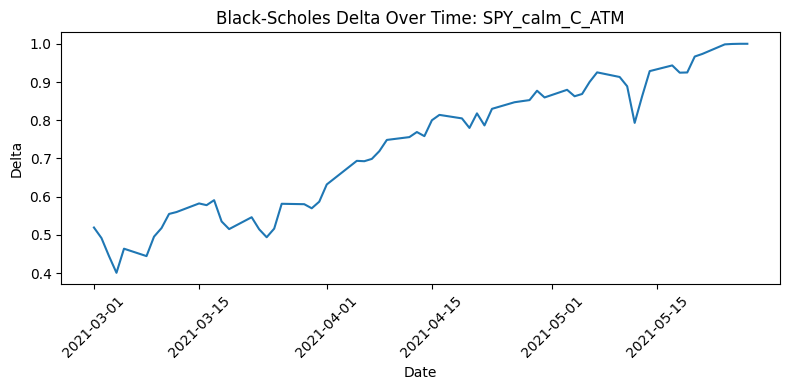

In [17]:
import matplotlib.pyplot as plt

sample_id = bs_panel["episode_id"].iloc[0]
sample = bs_panel[bs_panel["episode_id"] == sample_id].copy()

plt.figure(figsize=(8, 4))
plt.plot(sample["date"], sample["delta"])
plt.title(f"Black-Scholes Delta Over Time: {sample_id}")
plt.xlabel("Date")
plt.ylabel("Delta")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()